# DCN SU2015 debug

Thin debug notebook for the DCN comparison. NEURON loads the source HOC morphology and uses the repo-local renamed DCN mechanisms; BrainCell uses the native HOC parser path and does not depend on SWC/CSV.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainunit as u
from neuron import h


def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.neuron_compare.cell.dcn_su2015.debug.dcn_parameters import (
    DEFAULT_NRNMECH_PATH,
    SOURCE_MORPH_PATH,
    DcnConfig,
    DcnToggles,
    load_dcn15_params,
    toggle_names,
)
from examples.neuron_compare.cell.dcn_su2015.debug.dcn_neuron_debug import DCN as NeuronDCN
from examples.neuron_compare.cell.dcn_su2015.debug.dcn_braincell_debug import DCN as BrainCellDCN

import braincell
from braincell import mech
from braincell.filter import at
import brainstate
brainstate.environ.set(precision=64)

print("repo root:", REPO_ROOT)
print("braincell import:", braincell.__file__)
print("NEURON DCN mechanisms:", DEFAULT_NRNMECH_PATH)
print("source morphology:", SOURCE_MORPH_PATH)

--No graphics will be displayed.


repo root: /home/swl/braincell-ion_dyn
braincell import: /home/swl/braincell-ion_dyn/braincell/__init__.py
NEURON DCN mechanisms: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/DCN/x86_64/.libs/libnrnmech.so
source morphology: /home/swl/Cerebellum_circuit/DCN/DCN/DCN_mor.hoc


In [2]:
# Presets: "all", "leak_only", "no_tnc", "calcium_only", "manual".
# Use "manual" when you want direct control of every channel/ion below.
toggle_mode = "manual"

# Passive and tonic ohmic currents.
leak = True
tnc = True

# Sodium channels.
naf = True
nap = True

# Potassium channels.
fkdr = True
skdr = True
sk = True

# HCN current.
hcn = True

# Calcium channels and pools.
calva = True
cahva = True
ca_conc = True
cal_conc = True

manual_toggles = {
    "leak": leak,
    "tnc": tnc,
    "naf": naf,
    "nap": nap,
    "fkdr": fkdr,
    "skdr": skdr,
    "sk": sk,
    "hcn": hcn,
    "calva": calva,
    "cahva": cahva,
    "ca_conc": ca_conc,
    "cal_conc": cal_conc,
}


def make_toggles(mode="all", **overrides):
    names = toggle_names()
    if mode == "all":
        values = {name: True for name in names}
    elif mode == "leak_only":
        values = {name: False for name in names}
        values["leak"] = True
    elif mode == "no_tnc":
        values = {name: True for name in names}
        values["tnc"] = False
    elif mode == "calcium_only":
        values = {name: False for name in names}
        values.update({"leak": True, "calva": True, "cahva": True, "ca_conc": True, "cal_conc": True})
    elif mode == "manual":
        values = {name: bool(manual_toggles.get(name, False)) for name in names}
    else:
        raise ValueError(f"Unknown toggle_mode {mode!r}.")
    values.update({key: bool(value) for key, value in overrides.items()})
    return DcnToggles(**values)


# Example override: make_toggles("all", tnc=False, ca_conc=False, cal_conc=False)
toggles = make_toggles(toggle_mode)
config = DcnConfig(toggles=toggles, temperature_celsius=32.0, v_init_mV=-65.0)
params = load_dcn15_params(config)

dt_ms = 0.025
duration_ms = 80.0
delay_ms = 20.0
stim_dur_ms = 40.0
amp_nA = 0.1

rows = []
for group, names in {
    "ohmic": ["leak", "tnc"],
    "sodium": ["naf", "nap"],
    "potassium": ["fkdr", "skdr", "sk"],
    "hcn": ["hcn"],
    "calcium_channel": ["calva", "cahva"],
    "calcium_pool": ["ca_conc", "cal_conc"],
}.items():
    rows.extend({"group": group, "name": name, "enabled": getattr(toggles, name)} for name in names)

display(pd.DataFrame(rows))
print(f"toggle_mode={toggle_mode}")
print(f"dt={dt_ms} ms, duration={duration_ms} ms, clamp={amp_nA} nA")
print("Note: NEURON debug uses repo-local renamed DCN mechanisms. TNC is merged with leak into an equivalent pas current on NEURON side.")

,group,name,enabled
0,ohmic,leak,True
1,ohmic,tnc,True
2,sodium,naf,True
3,sodium,nap,True
4,potassium,fkdr,True
5,potassium,skdr,True
6,potassium,sk,True
7,hcn,hcn,True
8,calcium_channel,calva,True
9,calcium_channel,cahva,True


toggle_mode=manual
dt=0.025 ms, duration=80.0 ms, clamp=0.1 nA
Note: NEURON debug uses repo-local renamed DCN mechanisms. TNC is merged with leak into an equivalent pas current on NEURON side.


In [3]:
neuron_cell = NeuronDCN(
    params=params,
    config=config,
    nrnmech_path=DEFAULT_NRNMECH_PATH,
).build()
braincell_cell = BrainCellDCN(params=params, config=config).build()

summary_table = pd.DataFrame([neuron_cell.summary(), braincell_cell.summary()])
display(summary_table[["backend", "native_hoc", "branch_counts", "region_counts", "compartment_counts"]])
display(pd.Series(neuron_cell.summary(), dtype=object).rename("NEURON"))
display(pd.Series(braincell_cell.summary(), dtype=object).rename("BrainCell"))

,backend,native_hoc,branch_counts,region_counts,compartment_counts
0,neuron,True,"{'n_soma': 1, 'n_dend': 485, 'n_axon': 31, 'n_...","{'axHillock': 1, 'axIniSeg': 10, 'axNode': 20,...",{'n_total_nseg': 517}
1,braincell,True,"{'n_soma': 1, 'n_dend': 485, 'n_axon': 31, 'n_...","{'axHillock': 1, 'axIniSeg': 10, 'axNode': 20,...",{'n_total_cv': 517}


backend                                                          neuron
template_path         /home/swl/Cerebellum_circuit/DCN/DCN/DCN_templ...
morph_path             /home/swl/Cerebellum_circuit/DCN/DCN/DCN_mor.hoc
toggles               {'leak': True, 'naf': True, 'nap': True, 'fkdr...
nrnmech_path          /home/swl/braincell-ion_dyn/examples/neuron_co...
branch_counts         {'n_soma': 1, 'n_dend': 485, 'n_axon': 31, 'n_...
region_counts         {'axHillock': 1, 'axIniSeg': 10, 'axNode': 20,...
compartment_counts                                {'n_total_nseg': 517}
enabled_mechanisms    {'soma': ['leak', 'naf', 'nap', 'fkdr', 'skdr'...
native_hoc                                                         True
Name: NEURON, dtype: object

backend                                                       braincell
morph_path             /home/swl/Cerebellum_circuit/DCN/DCN/DCN_mor.hoc
toggles               {'leak': True, 'naf': True, 'nap': True, 'fkdr...
branch_counts         {'n_soma': 1, 'n_dend': 485, 'n_axon': 31, 'n_...
region_counts         {'axHillock': 1, 'axIniSeg': 10, 'axNode': 20,...
compartment_counts                                  {'n_total_cv': 517}
enabled_mechanisms    {'soma': ['leak', 'naf', 'nap', 'fkdr', 'skdr'...
native_hoc                                                         True
Name: BrainCell, dtype: object

In [4]:
neuron_branches = neuron_cell.branch_table()
braincell_branches = braincell_cell.branch_table()

display(neuron_branches.head())
display(braincell_branches.head())

region_compare = pd.concat(
    [
        neuron_branches.groupby("source_region").agg(neuron_sections=("branch_index", "count"), neuron_nseg=("nseg", "sum")),
        braincell_branches.groupby("source_region").agg(braincell_branches=("branch_index", "count"), braincell_cv=("n_cv", "sum")),
    ],
    axis=1,
).fillna(0).astype(int)
display(region_compare)

,branch_index,branch_name,source_section,branch_type,source_region,source_local_index,diam_um,cm_uF_cm2,ra_ohm_cm,nseg,...,has_calva,has_fkdr,has_hcn,has_leak,has_naf,has_nap,has_sk,has_skdr,has_tnc,enabled_mechanisms
0,0,soma,soma,soma,soma,0,14.398,1.57,235.3,1,...,True,True,True,True,True,True,True,True,True,"[ca_conc, cahva, cal_conc, calva, fkdr, hcn, l..."
1,1,axHill,axHill,axon,axHillock,0,4.750,1.57,235.3,1,...,False,True,False,True,True,False,False,True,True,"[fkdr, leak, naf, skdr, tnc]"
2,2,axIS[0],axIS[0],axon,axIniSeg,0,1.500,1.57,235.3,1,...,False,True,False,True,True,False,False,True,True,"[fkdr, leak, naf, skdr, tnc]"
3,3,axIS[1],axIS[1],axon,axIniSeg,1,1.500,1.57,235.3,1,...,False,True,False,True,True,False,False,True,True,"[fkdr, leak, naf, skdr, tnc]"
4,4,axIS[2],axIS[2],axon,axIniSeg,2,1.500,1.57,235.3,1,...,False,True,False,True,True,False,False,True,True,"[fkdr, leak, naf, skdr, tnc]"


,branch_index,branch_name,source_section,branch_type,source_region,source_local_index,diam_arc_mean_um,cm_uF_cm2,ra_ohm_cm,n_cv,...,has_calva,has_fkdr,has_hcn,has_leak,has_naf,has_nap,has_sk,has_skdr,has_tnc,enabled_mechanisms
0,0,soma,soma,soma,soma,0,14.398,1.57,235.3,1,...,True,True,True,True,True,True,True,True,True,"[ca_conc, cahva, cal_conc, calva, fkdr, hcn, l..."
1,1,axHillock__axHill,axHill,axon,axHillock,0,4.750,1.57,235.3,1,...,False,True,False,True,True,False,False,True,True,"[fkdr, leak, naf, skdr, tnc]"
2,2,proxDend__p3__0,p3[0],dendrite,proxDend,0,2.978,1.57,235.3,1,...,True,True,True,True,True,False,True,True,True,"[ca_conc, cahva, cal_conc, calva, fkdr, hcn, l..."
3,3,proxDend__p2__0,p2[0],dendrite,proxDend,1,2.669,1.57,235.3,1,...,True,True,True,True,True,False,True,True,True,"[ca_conc, cahva, cal_conc, calva, fkdr, hcn, l..."
4,4,proxDend__p1__0,p1[0],dendrite,proxDend,2,2.520,1.57,235.3,1,...,True,True,True,True,True,False,True,True,True,"[ca_conc, cahva, cal_conc, calva, fkdr, hcn, l..."


,neuron_sections,neuron_nseg,braincell_branches,braincell_cv
source_region,,,,
axHillock,1,1,1,1
axIniSeg,10,10,10,10
axNode,20,20,20,20
distDend,402,402,402,402
proxDend,83,83,83,83
soma,1,1,1,1


In [5]:
DT_MS = dt_ms
DURATION_MS = duration_ms
DELAY_MS = delay_ms
STIM_DUR_MS = stim_dur_ms
AMP_NA = amp_nA

nrn_probes = neuron_cell.attach_voltage_probes(all_compartments=True, soma=True)
bc_probes = braincell_cell.attach_voltage_probes(all_compartments=True, soma=True)

stim = h.IClamp(neuron_cell.root_soma(0.5))
stim.delay = DELAY_MS
stim.dur = STIM_DUR_MS
stim.amp = AMP_NA
stim_i = h.Vector().record(stim._ref_i)
h.cvode_active(0)
h.dt = DT_MS
h.steps_per_ms = 1.0 / h.dt
h.celsius = config.temperature_celsius
h.tstop = DURATION_MS
h.v_init = config.v_init_mV
t_neuron = h.Vector().record(h._ref_t)
h.finitialize(h.v_init)
h.run()

braincell_cell.cell.place(
    at("soma", 0.5),
    mech.CurrentClamp.step(AMP_NA * u.nA, STIM_DUR_MS * u.ms, delay=DELAY_MS * u.ms),
)
braincell_cell.cell.init_state()
braincell_cell.cell.reset_state()
bc_run = braincell_cell.cell.run(dt=DT_MS * u.ms, duration=DURATION_MS * u.ms)

nrn_v = neuron_cell.collect_voltage_results(nrn_probes)
bc_v = braincell_cell.collect_voltage_results(bc_probes, bc_run)
t_neuron = np.asarray(t_neuron, dtype=float)
stim_i = np.asarray(stim_i, dtype=float)
t_bc = np.arange(1, len(bc_v["soma_voltage_mV"]) + 1, dtype=float) * DT_MS
nrn_soma_for_bc = np.interp(t_bc, t_neuron, nrn_v["soma_voltage_mV"])
soma_delta = bc_v["soma_voltage_mV"] - nrn_soma_for_bc

{
    "applied_amp_nA": float(AMP_NA),
    "neuron_stim_i_max_nA": float(np.max(stim_i)) if len(stim_i) else None,
    "neuron_stim_i_min_nA": float(np.min(stim_i)) if len(stim_i) else None,
    "n_neuron_samples": int(len(t_neuron)),
    "n_braincell_samples": int(len(t_bc)),
    "soma_rmse_mV": float(np.sqrt(np.mean(soma_delta ** 2))),
    "soma_mean_abs_mV": float(np.mean(np.abs(soma_delta))),
    "soma_max_abs_mV": float(np.max(np.abs(soma_delta))),
}

{'applied_amp_nA': 0.1,
 'neuron_stim_i_max_nA': 0.1,
 'neuron_stim_i_min_nA': 0.0,
 'n_neuron_samples': 3201,
 'n_braincell_samples': 3200,
 'soma_rmse_mV': 0.5899541484635571,
 'soma_mean_abs_mV': 0.07851877852900119,
 'soma_max_abs_mV': 10.358298080207762}

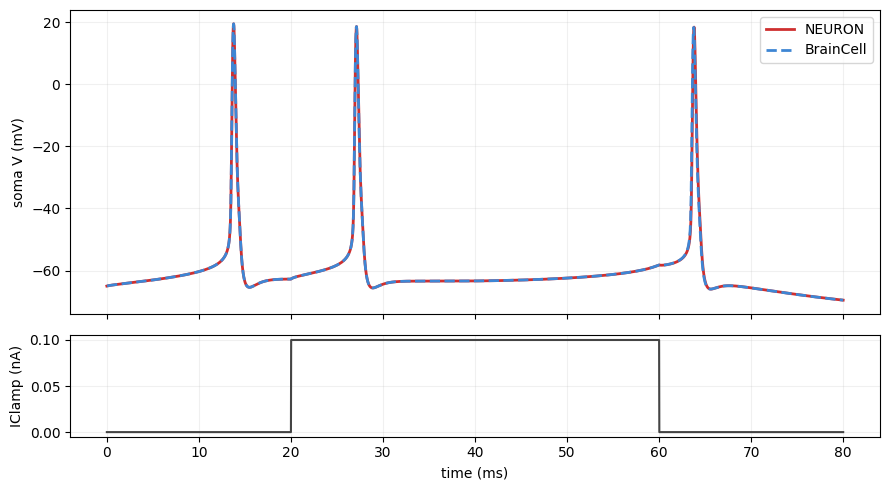

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, height_ratios=(3, 1))
axes[0].plot(t_neuron, nrn_v["soma_voltage_mV"], label="NEURON", color="#CE2F2F", lw=2)
axes[0].plot(t_bc, bc_v["soma_voltage_mV"], label="BrainCell", color="#3E86D4", ls="--", lw=2)
axes[0].set_ylabel("soma V (mV)")
axes[0].legend()
axes[0].grid(alpha=0.18)

axes[1].plot(t_neuron, stim_i, color="#444444", lw=1.5)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("IClamp (nA)")
axes[1].grid(alpha=0.18)
fig.tight_layout()

In [7]:
reference_time_ms = np.round(np.arange(0.0, DURATION_MS, DT_MS, dtype=float), decimals=12)


def trim_neuron_time_axis(values, reference_time_ms):
    values = np.asarray(values, dtype=float)
    if values.shape[0] == reference_time_ms.shape[0] + 1:
        return values[1:]
    return values


neuron_soma = trim_neuron_time_axis(nrn_v["soma_voltage_mV"], reference_time_ms)
neuron_comp = trim_neuron_time_axis(nrn_v["compartment_voltage_mV"], reference_time_ms)
braincell_soma = np.asarray(bc_v["soma_voltage_mV"], dtype=float).reshape(-1)
braincell_comp = np.asarray(bc_v["compartment_voltage_mV"], dtype=float)

n_time = min(neuron_comp.shape[0], braincell_comp.shape[0])
neuron_comp = neuron_comp[:n_time, :]
braincell_comp = braincell_comp[:n_time, :]
metric_time_ms = reference_time_ms[:n_time]

pair_table = pd.merge(
    bc_v["compartment_table"],
    nrn_v["compartment_table"],
    on=["source_section", "local_index"],
    suffixes=("_braincell", "_neuron"),
    validate="one_to_one",
)
metric_rows = []
for row in pair_table.itertuples(index=False):
    bc_idx = int(row.compartment_index_braincell)
    nrn_idx = int(row.compartment_index_neuron)
    delta = braincell_comp[:, bc_idx] - neuron_comp[:, nrn_idx]
    metric_rows.append(
        {
            "source_region": row.source_region_braincell,
            "source_section": row.source_section,
            "source_local_index_braincell": int(row.source_local_index_braincell),
            "source_local_index_neuron": int(row.source_local_index_neuron),
            "local_index": int(row.local_index),
            "branch_name_braincell": row.branch_name_braincell,
            "branch_name_neuron": row.branch_name_neuron,
            "mean_abs_mV": float(np.mean(np.abs(delta))),
            "rmse_mV": float(np.sqrt(np.mean(delta ** 2))),
            "max_abs_mV": float(np.max(np.abs(delta))),
        }
    )
compartment_metrics = pd.DataFrame(metric_rows)
soma_delta_aligned = braincell_soma[:n_time] - neuron_soma[:n_time]
metric_table = pd.DataFrame(
    [
        {
            "metric": "soma_v_rmse_mV",
            "value": float(np.sqrt(np.mean(soma_delta_aligned ** 2))),
        },
        {
            "metric": "soma_v_mean_abs_mV",
            "value": float(np.mean(np.abs(soma_delta_aligned))),
        },
        {
            "metric": "soma_v_max_abs_mV",
            "value": float(np.max(np.abs(soma_delta_aligned))),
        },
        {
            "metric": "compartment_v_mean_of_rmse_mV",
            "value": float(compartment_metrics["rmse_mV"].mean()),
        },
        {
            "metric": "compartment_v_mean_of_mean_abs_mV",
            "value": float(compartment_metrics["mean_abs_mV"].mean()),
        },
        {
            "metric": "compartment_v_global_max_abs_mV",
            "value": float(compartment_metrics["max_abs_mV"].max()),
        },
    ]
)
display(metric_table)
display(compartment_metrics.sort_values("max_abs_mV", ascending=False).head(20))

,metric,value
0,soma_v_rmse_mV,0.589954
1,soma_v_mean_abs_mV,0.078519
2,soma_v_max_abs_mV,10.358298
3,compartment_v_mean_of_rmse_mV,0.213916
4,compartment_v_mean_of_mean_abs_mV,0.038550
5,compartment_v_global_max_abs_mV,10.647329


,source_region,source_section,source_local_index_braincell,source_local_index_neuron,local_index,branch_name_braincell,branch_name_neuron,mean_abs_mV,rmse_mV,max_abs_mV
102,axIniSeg,axIS[7],7,7,0,axIniSeg__axIS__7,axIS[7],0.081294,0.612999,10.647329
83,axIniSeg,axIS[6],6,6,0,axIniSeg__axIS__6,axIS[6],0.081201,0.612198,10.641223
127,axIniSeg,axIS[8],8,8,0,axIniSeg__axIS__8,axIS[8],0.081278,0.612832,10.636891
63,axIniSeg,axIS[5],5,5,0,axIniSeg__axIS__5,axIS[5],0.080997,0.610512,10.616978
155,axIniSeg,axIS[9],9,9,0,axIniSeg__axIS__9,axIS[9],0.081156,0.611640,10.610657
47,axIniSeg,axIS[4],4,4,0,axIniSeg__axIS__4,axIS[4],0.080679,0.608058,10.572148
32,axIniSeg,axIS[3],3,3,0,axIniSeg__axIS__3,axIS[3],0.080346,0.604982,10.503438
12,axIniSeg,axIS[1],1,1,0,axIniSeg__axIS__1,axIS[1],0.079536,0.597714,10.414453
6,axIniSeg,axIS[0],0,0,0,axIniSeg__axIS__0,axIS[0],0.078972,0.593979,10.413853
21,axIniSeg,axIS[2],2,2,0,axIniSeg__axIS__2,axIS[2],0.079989,0.601463,10.406696


,n_compartments,mean_abs_mV,rmse_mV,max_abs_mV
source_region,,,,
axIniSeg,10,0.080545,0.606638,10.647329
axHillock,1,0.078675,0.591620,10.395566
soma,1,0.078519,0.589954,10.358298
proxDend,83,0.063968,0.437491,10.149717
axNode,20,0.049855,0.324332,9.756750
distDend,402,0.031495,0.150617,7.290396


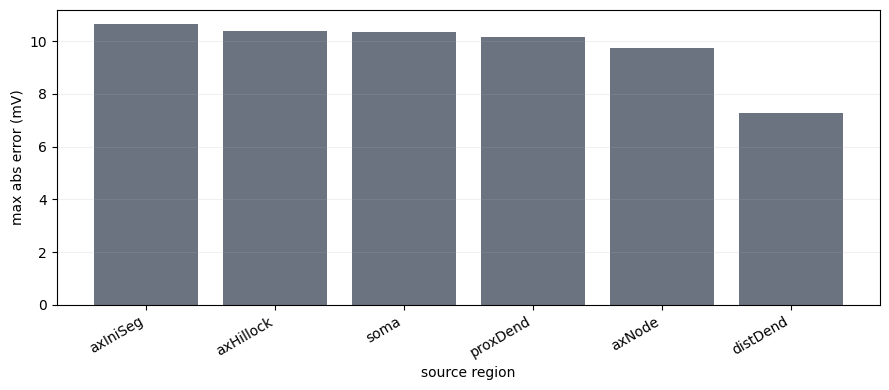

In [8]:
region_metrics = compartment_metrics.groupby("source_region").agg(
    n_compartments=("max_abs_mV", "count"),
    mean_abs_mV=("mean_abs_mV", "mean"),
    rmse_mV=("rmse_mV", "mean"),
    max_abs_mV=("max_abs_mV", "max"),
).sort_values("max_abs_mV", ascending=False)
display(region_metrics)

plt.figure(figsize=(9, 4))
plt.bar(region_metrics.index, region_metrics["max_abs_mV"], color="#6B7280")
plt.ylabel("max abs error (mV)")
plt.xlabel("source region")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.18)
plt.tight_layout()

In [9]:
# Optional cleanup when re-running cells in the same kernel.
# neuron_cell.cleanup()